In [1]:
# STalign path configuration (auto-generated)
from pathlib import Path
import os
import re
import pandas as pd
import numpy as np

from PIL import Image
def detect_workdir() -> str:
    home = os.path.expanduser("~")
    if home in ["/Users/youyun", "/Users/youyunzheng"]:
        return home + "/Documents/HMS/PhD/beroukhimlab/dfci_mount/"
    if home == "/home/yz762":
        return "/mnt/storage/dept/medonc/beroukhim/"
    if home == "/PHShome/yz762":
        return "/data/beroukhim1/"
    return "/data/beroukhim1/"


WORKDIR = Path(detect_workdir())
XENIUM_ANNOT_ROOT = WORKDIR / "youyun/plgg/data/Xenium_annotations"
PROSEG_ROOT = WORKDIR / "youyun/plgg/data/segmentation/proseg_run_121024"
METADATA_XLSX = WORKDIR / "youyun/plgg/data/metadata/Xenium_PS.xlsx"
OUTPUT_ROOT = WORKDIR / "youyun/plgg/data/Xenium_annotations/pathology_annotations_030226"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

SAMPLE_ID = "PA188570"
IMAGE_GROUP = "LGG1"

GEOJSON_PATH = XENIUM_ANNOT_ROOT / "geojsons" / "230918_Xenium_CytAssist_LGG1_merged.geojson"
if not GEOJSON_PATH.exists():
    raise FileNotFoundError(
        f"Missing canonical GeoJSON for {SAMPLE_ID}: {GEOJSON_PATH}. "
        "GeoJSON files are assumed to be pre-staged under geojsons/, including LGG1_merged."
    )

IMAGE_JPG_ROOT = XENIUM_ANNOT_ROOT / "images"
IMAGE_FILE = IMAGE_JPG_ROOT / f"230918_Xenium_CytAssist_{IMAGE_GROUP}.jpg"
if not IMAGE_FILE.exists():
    raise FileNotFoundError(
        f"Missing JPG image for {SAMPLE_ID}: {IMAGE_FILE}. "
        "JPG images are assumed to be pre-staged under images/."
    )

def read_jpg(path: Path) -> np.ndarray:
    img = np.asarray(Image.open(path).convert("RGB"))
    return img

def resolve_cells_csv(sample_id: str) -> Path:
    metadata = pd.read_excel(METADATA_XLSX)
    numeric_id = re.sub(r"^[A-Za-z]+", "", sample_id)
    matches = metadata.loc[metadata["id"].astype(str) == numeric_id, "file"]
    if matches.empty:
        raise ValueError(f"Could not find sample {sample_id} in metadata: {METADATA_XLSX}")

    file_name = matches.iloc[0]
    cells_csv = PROSEG_ROOT / file_name / f"{file_name}_proseg" / "outs" / "cells.csv.gz"
    if not cells_csv.exists():
        raise FileNotFoundError(f"cells.csv.gz missing for {sample_id}: {cells_csv}")
    return cells_csv


CELL_CSV_PATH = resolve_cells_csv(SAMPLE_ID)
OUTPUT_FILE = OUTPUT_ROOT / f"proseg_pathology_{SAMPLE_ID}_proseg_meta.csv"


In [2]:
import matplotlib.pyplot as plt
import geopandas as gpd
import geoplot
import geoplot.crs as gcrs
import pandas as pd
import numpy as np
from STalign import STalign
import seaborn as sns
from shapely.geometry import shape, GeometryCollection, Point
import scipy

Methods

In [3]:
# Function to convert a string to a tuple
def string_to_tuple(text):
  return tuple(text.split(','))
    
def rgb2hex(r,g,b):
    hex = "#{:02x}{:02x}{:02x}".format(r,g,b)
    return hex

In [4]:
def geojson_contains_xy(geojson, xy):
    if s.contains(xy).any():
        return s[s.contains(Point(xy))]['color'].values[0]
    else:
        return "unannotated"

# H&E and Geojson

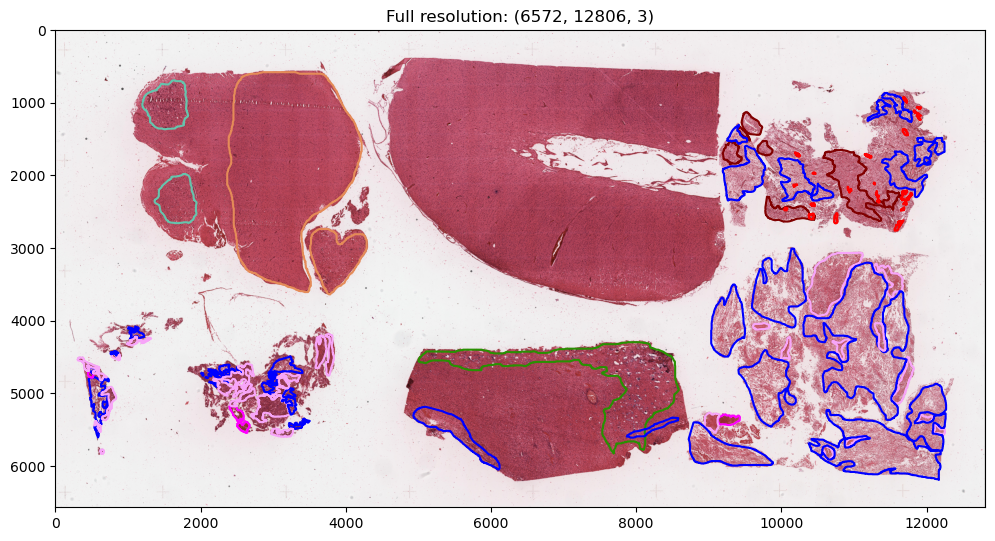

In [8]:
import json
# Plot the full resolution and downsampled images side-by-side
fig, ax = plt.subplots(1, figsize=(12, 12))
fullres_img_tiff = read_jpg(IMAGE_FILE)
ax.imshow(fullres_img_tiff, cmap="gray")
ax.set_title(f"Full resolution: {fullres_img_tiff.shape}")

# Convert GeoJSON to a GeoDataFrame
df_geojson = gpd.read_file(GEOJSON_PATH)
s = gpd.GeoDataFrame(df_geojson)
classification_str = s['classification'].astype(str)
s["name"] = s["classification"].apply(lambda t: json.loads(t).get("name"))
s["rgb"] = s["classification"].apply(lambda t: json.loads(t).get("color"))
s["color"] = s["rgb"].apply(lambda c: rgb2hex(int(c[0]), int(c[1]), int(c[2])))
# scale down the geometry by 7 to match the downsampled image
s.geometry = s.geometry.scale(xfact=1/7, yfact=1/7, origin=(0, 0))
# Plot
s.boundary.plot(ax=ax,color=s['color'], aspect = 1)

plt.show()

# ST Align

0.0
1.0


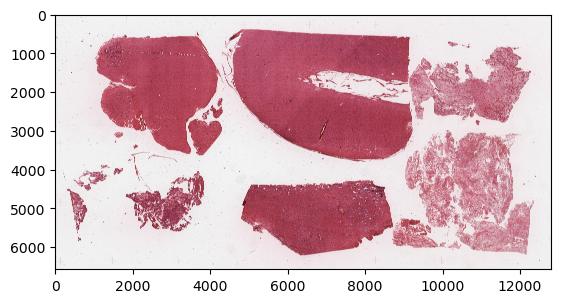

In [7]:
from STalign import STalign
image_file = str(IMAGE_FILE)
V = read_jpg(IMAGE_FILE)
Inorm = STalign.normalize(V)

print(Inorm.min())
print(Inorm.max())

fig,ax = plt.subplots()
ax.imshow(Inorm)

In [9]:
I = Inorm.transpose(2,0,1)
print(I.shape)

YI = np.array(range(I.shape[1]))*1. # needs to be longs not doubles for STalign.transform later so multiply by 1.
XI = np.array(range(I.shape[2]))*1. # needs to be longs not doubles for STalign.transform later so multiply by 1.
extentI = STalign.extent_from_x((YI,XI))

(3, 6572, 12806)


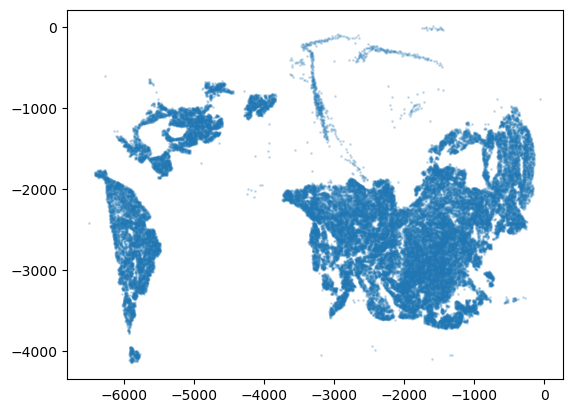

In [10]:
cell_csv = pd.read_csv(CELL_CSV_PATH)
# get cell centroid coordinates
xM = -np.array(cell_csv['y_centroid'])
yM = -np.array(cell_csv['x_centroid'])

# plot
fig,ax = plt.subplots()
ax.scatter(xM,yM,s=1,alpha=0.2)

0 of 50318
10000 of 50318
20000 of 50318
30000 of 50318
40000 of 50318
50000 of 50318
50317 of 50318


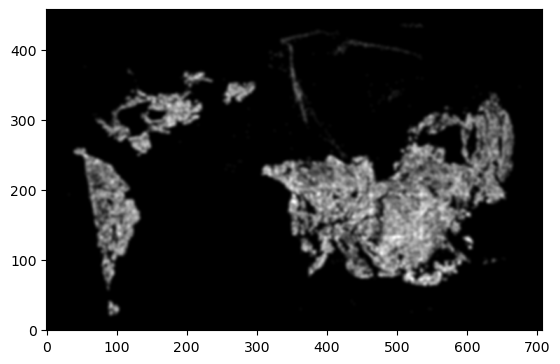

In [11]:
# rasterize at 30um resolution (assuming positions are in um units) and plot
XJ,YJ,M,fig = STalign.rasterize(xM, yM, dx=10)

ax = fig.axes[0]
ax.invert_yaxis()

In [12]:
print(M.shape)
J = np.vstack((M, M, M)) # make into 3xNxM
print(J.min())
print(J.max())

# normalize
J = STalign.normalize(J)
print(J.min())
print(J.max())

# double check size of things
print(I.shape)
print(M.shape)
print(J.shape)

(1, 458, 708)
0.0
1.6948586346772112
0.0
1.0
(3, 6572, 12806)
(1, 458, 708)
(3, 458, 708)


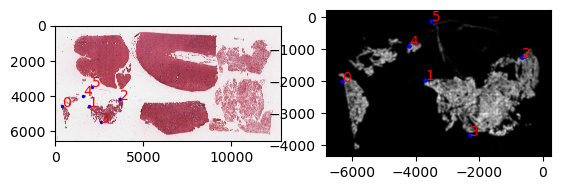

In [13]:
# manually make corresponding points
pointsI = np.array([[4600.,400.],[4600., 1900.],
                    [4200., 3700.],[5500.,2600],
                    [4000,1600],[3500,2100]])
pointsJ = np.array([[-2000.,-6300.],[-1950., -3700.],
                    [-1250., -650.],[-3700.,-2300],
                    [-900,-4200],[-100,-3500]])

# plot
extentJ = STalign.extent_from_x((YJ,XJ))

fig,ax = plt.subplots(1,2)
ax[0].imshow((I.transpose(1,2,0).squeeze()), extent=extentI)
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ)

ax[0].scatter(pointsI[:,1],pointsI[:,0], c='blue',s=2)
ax[1].scatter(pointsJ[:,1],pointsJ[:,0], c='blue',s=5)
for i in range(pointsI.shape[0]):
    ax[0].text(pointsI[i,1],pointsI[i,0],f'{i}', c='red')
    ax[1].text(pointsJ[i,1],pointsJ[i,0],f'{i}', c='red')

# invert only rasterized image
ax[1].invert_yaxis()

In [14]:
# compute initial affine transformation from points
L,T = STalign.L_T_from_points(pointsI,pointsJ)

[[-1.80864265 -0.00243814]
 [ 0.14940866  1.7272016 ]]
[ 6313.02583697 -7639.82805677]
(2, 2)
(2,)
(2, 50318)


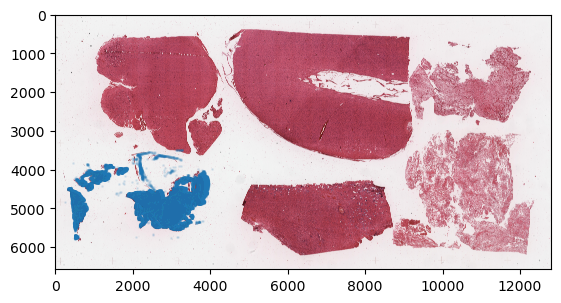

In [15]:
print(L)
print(T)
print(L.shape)
print(T.shape)

# note points are as y,x
affine = np.dot(np.linalg.inv(L), [yM - T[0], xM - T[1]])
print(affine.shape)
xMaffine = affine[0,:]
yMaffine = affine[1,:]

# plot
fig,ax = plt.subplots()
ax.scatter(yMaffine,xMaffine,s=1,alpha=0.1)
ax.imshow((I).transpose(1,2,0))

In [13]:
import torch
# set device for building tensors
if torch.cuda.is_available():
    torch.set_default_device('cuda:0')
else:
    torch.set_default_device('cpu')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3484.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/STalign/STalign.py:1301: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axE[2].set_yscale('log')


CPU times: user 6min 48s, sys: 3min 34s, total: 10min 22s
Wall time: 5min 8s


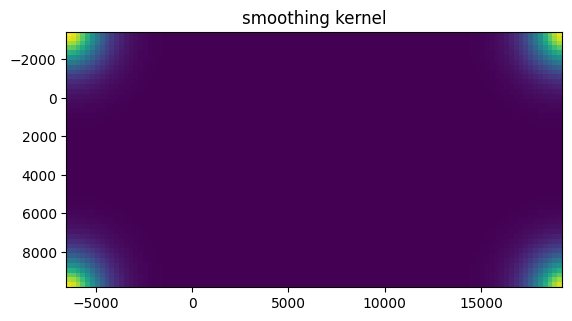

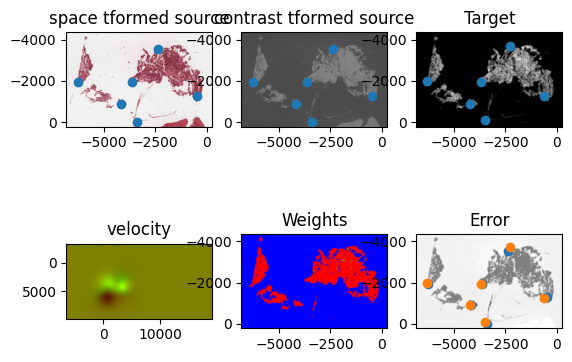

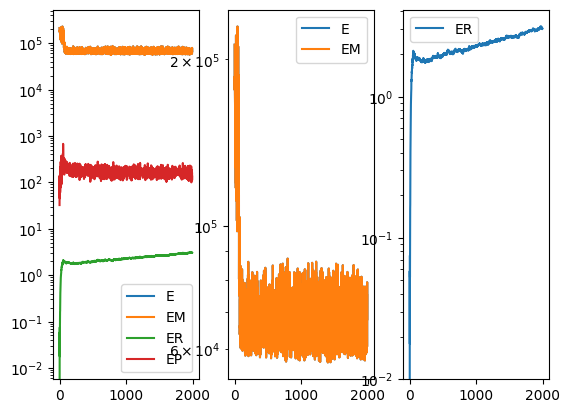

In [14]:
%%time

# run LDDMM
# specify device (default device for STalign.LDDMM is cpu)
if torch.cuda.is_available():
    device = 'cuda:0'
else:
    device = 'cpu'

# keep all other parameters default
params = {'L':L,'T':T,
          'niter':2000,
          'pointsI':pointsI,
          'pointsJ':pointsJ,
          'device':device,
          'sigmaM':0.15,
          'sigmaB':0.10,
          'sigmaA':0.11,
          'epV': 10,
          'muB': torch.tensor([0,0,0]), # black is background in target
          'muA': torch.tensor([1,1,1]) # use white as artifact
          }

out = STalign.LDDMM([YI,XI],I,[YJ,XJ],J,**params)

In [15]:
# get necessary output variables
A = out['A']
v = out['v']
xv = out['xv']

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/utils/_device.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


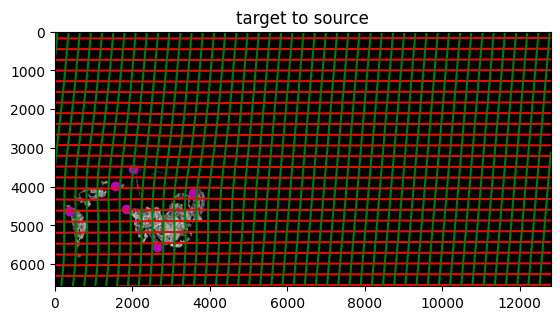

In [16]:
# now transform the points
phi = STalign.build_transform(xv,v,A,XJ=[YI,XI],direction='f')
phiiJ = STalign.transform_image_target_to_source(xv,v,A,[YJ,XJ],J,[YI,XI])
phiipointsJ = STalign.transform_points_target_to_source(xv,v,A,pointsJ)

#switch tensor from cuda to cpu for plotting with numpy
if phi.is_cuda:
    phi = phi.cpu()
if phiiJ.is_cuda:
    phiiJ = phiiJ.cpu()
if phiipointsJ.is_cuda:
    phiipointsJ = phiipointsJ.cpu()

# plot
fig,ax = plt.subplots()

levels = np.arange(-50000,50000,500)

ax.contour(XI,YI,phi[...,0],colors='r',linestyles='-',levels=levels)
ax.contour(XI,YI,phi[...,1],colors='g',linestyles='-',levels=levels)
ax.set_aspect('equal')
ax.set_title('target to source')

ax.imshow(phiiJ.permute(1,2,0),extent=extentI)
ax.scatter(phiipointsJ[:,1].detach(),phiipointsJ[:,0].detach(),c="m")

In [17]:
# Now apply to points
tpointsJ = STalign.transform_points_target_to_source(xv,v,A,np.stack([yM, xM], -1))

#switch tensor from cuda to cpu for plotting with numpy
if tpointsJ.is_cuda:
    tpointsJ = tpointsJ.cpu()

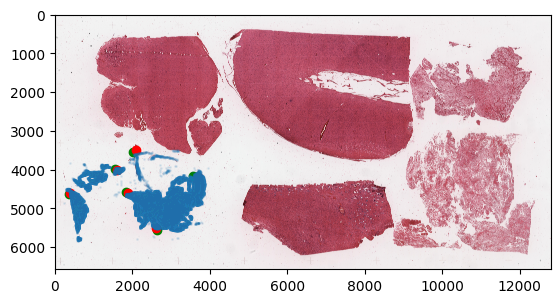

In [18]:
###### plot
fig,ax = plt.subplots()
ax.imshow((I).transpose(1,2,0),extent=extentI)
ax.scatter(phiipointsJ[:,1].detach(),phiipointsJ[:,0].detach(),c="g")
ax.scatter(pointsI[:,1],pointsI[:,0], c='r')
ax.scatter(tpointsJ[:,1].detach(),tpointsJ[:,0].detach(),s=1,alpha=0.1)

# Geojson Scaling

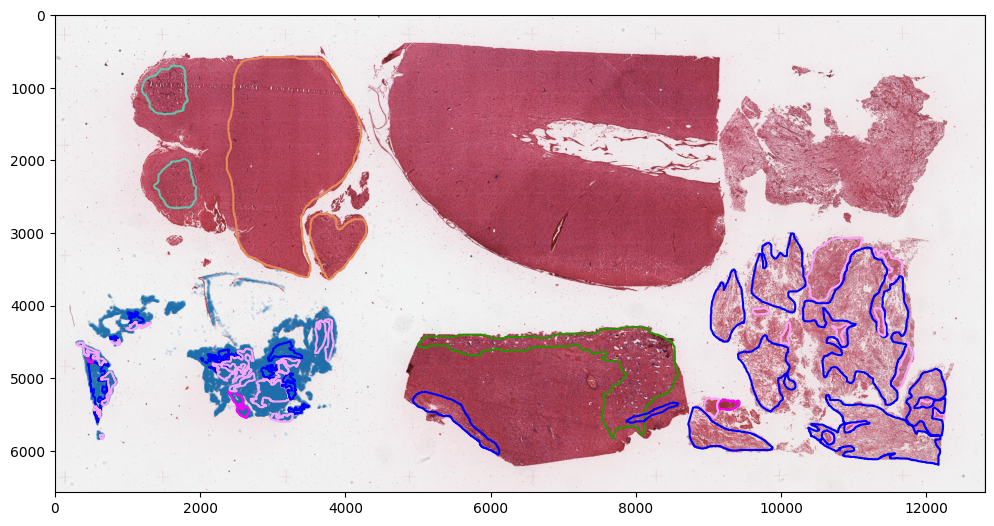

In [20]:
# Read in geojson and add color based on annotation

df_geojson = gpd.read_file(GEOJSON_PATH)
s = gpd.GeoDataFrame(df_geojson)
classification_str = s['classification'].astype(str)
s['name'] = classification_str.str.split("'", expand = True)[3]
s['color'] = classification_str.str.split('[', expand = True)[1].str.split(']', expand = True)[0].apply(string_to_tuple)
s['color'] = s['color'].apply(lambda x: 
                              rgb2hex(int(x[0]),int(x[1]),int(x[2]))
                             )
# scale
s.geometry = s.geometry.scale(xfact=1/7, yfact=1/7, origin=(0,0))

# Read in H&E Image
image_file = str(IMAGE_FILE)
V = read_jpg(IMAGE_FILE)

### Plot
# H&E
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(V)
#Geojson
s.boundary.plot(ax=ax,color=s['color'],aspect=1)
# STAlign adjusted Xenium
ax.scatter(tpointsJ[:,1].detach(),tpointsJ[:,0].detach(),s=1,alpha=0.1)
plt.show()

# Annotation Plotting

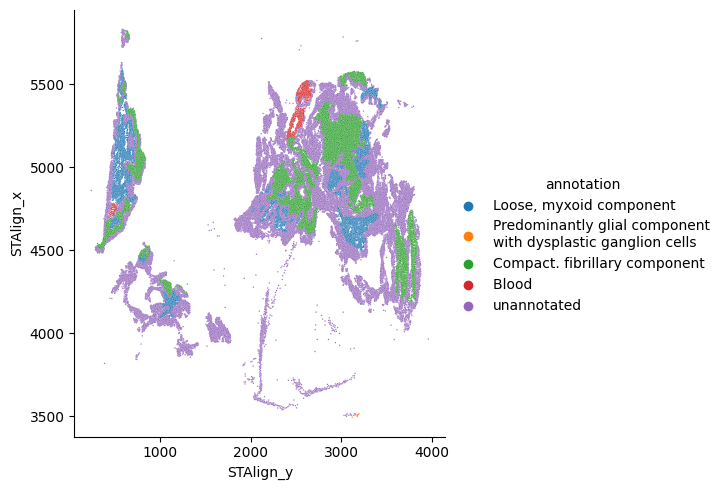

In [21]:
results = np.hstack((cell_csv, tpointsJ.numpy()))
results = pd.DataFrame(results)

names = list(cell_csv.columns)
names.append("STAlign_x")
names.append("STAlign_y")
names

results.columns = names
results['adjust_xy'] = list(zip(results['STAlign_y'], results['STAlign_x']))
results['annotation'] = results['adjust_xy'].apply(lambda x: geojson_contains_xy(s,Point(x)))
results['annotation'] =results['annotation'].astype('category')

recode_map = {
'#0000ff':'Loose, myxoid component',
'#f7a5f8':'Compact. fibrillary component',
'#ff00ff':'Blood ',
'#66c4ad':'Dysplastic Neurons / Ganglion Cells',
'#e48b58':'Predominantly glial component\nwith dysplastic ganglion cells',
'#299002':'Highly Calcified Area',
'unannotated':'unannotated'
}
results['annotation'] = results['annotation'].replace(recode_map)

sns.relplot(data=results, x='STAlign_y', y='STAlign_x',s=1,hue='annotation')
plt.show()

In [22]:
results.to_csv(OUTPUT_FILE, index=False)